# Loading the Dataset

In [67]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 


df = pd.read_csv('Titanic.csv')

# Analysing the Data

In [68]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape #891 rows and 12 columns

(891, 12)

In [70]:
df.info() #Shape has 891 rows and we can see that there are some missing values in the Age, Cabin and Embarked columns

#means some data is missing 

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Handling null values

In [71]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age is having 177, cabin is having 687 and Embarked is having 2 missing values

In [72]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Observations 

1) AGE range = around 4 months old child to 80 year old senior citizen 
2) there are two unique sex "Male" and "Female"
3) Male were in dominating number than female
4) Average age was around 29 to 30 
5) around 38% people survived



In [73]:
df.duplicated().sum() #No duplicates in the dataset

np.int64(0)

# Cleaning the Data

In [74]:
df["Age"] = df["Age"].fillna(df["Age"].median()) #filling the NULL values in Age column with average value of the column 

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0]) #there were only two null values in embarked column so we are filling them with the most frequent value that is 'S'

#Embarked means to get on a ship In this case, it refers to the port where the passengers boarded the titanic The three ports are Southampton (S), Cherbourg (C), and Queenstown (Q).

In [ ]:
df.drop(columns=["Cabin"] , inplace = True) #Cabin is having 687 missing values which cannot be filled with precision so we are dropping the column from the dataset

# Exploratory Data Analysis (EDA)

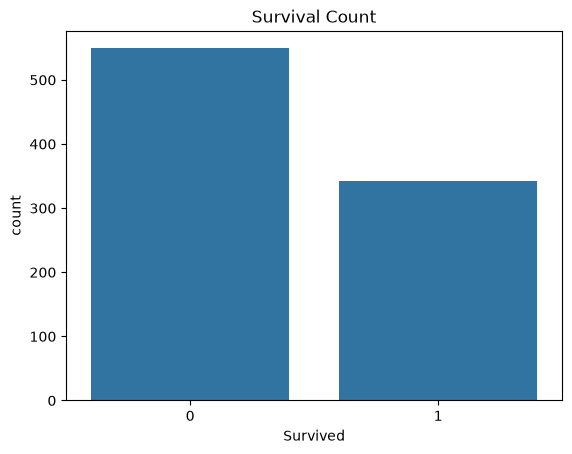

In [93]:
sns.countplot(x="Survived" , data = df ) #More Male than Females Visualized here seen above

plt.title("Survival Count")
plt.savefig("survival_count.png")
plt.show()

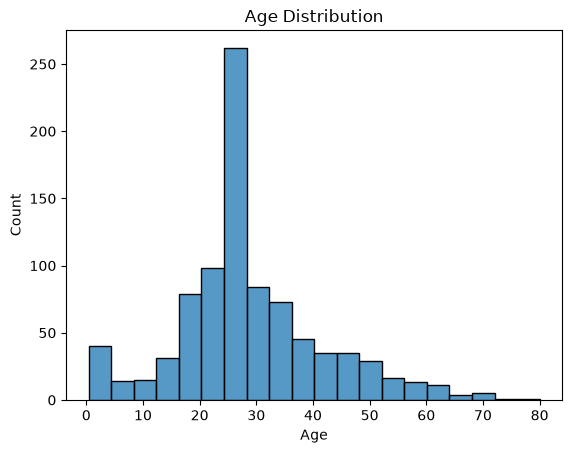

In [99]:
sns.histplot(x="Age", bins=20, data=df)

plt.title("Age Distribution")
plt.savefig("age_distribution.png")
plt.show()

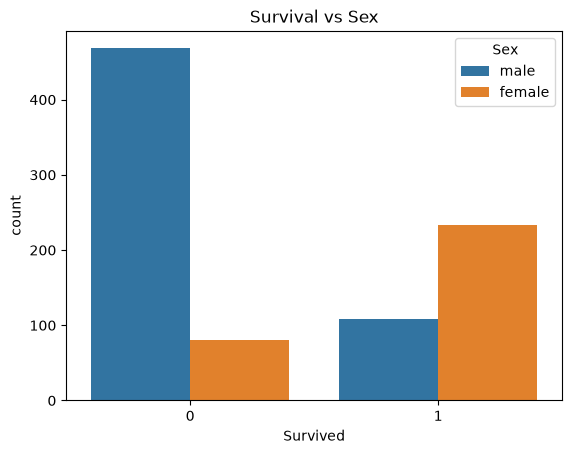

In [94]:
sns.countplot(x="Survived" , hue="Sex" , data = df)

plt.title("Survival vs Sex")
plt.savefig("survival_vs_sex.png")
plt.show()

More Females SURVIVED than Men 
This shows that men might have sacrificed their lives protecting females

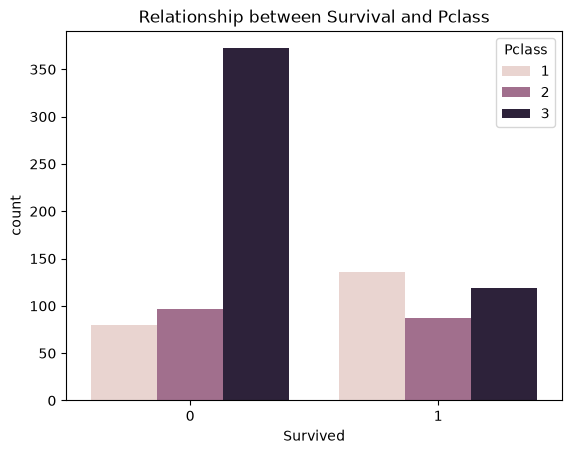

In [95]:
sns.countplot(x="Survived", hue="Pclass" , data = df)

plt.title("Relationship between Survival and Pclass")
plt.savefig("survival_vs_pclass.png")
plt.show()

Observations

1) This shows that Chances of Survival were more for the first class Passengers

 and this is natural cause the gave more money so their cabins were also made for a reason

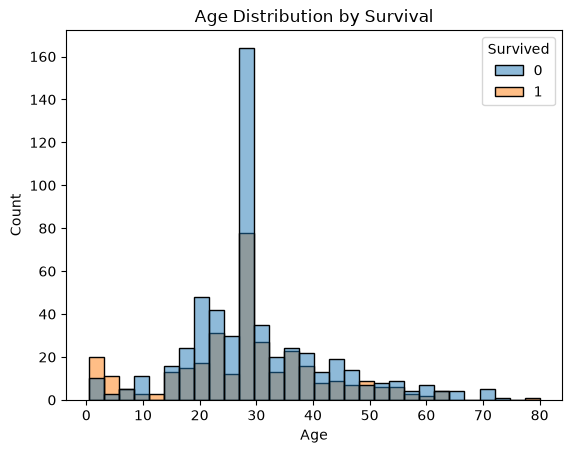

In [100]:
sns.histplot(x="Age" , hue='Survived',data = df)

plt.title("Age Distribution by Survival")
plt.savefig("age_distribution_by_survival.png")
plt.show()

Observations:
1) Most Passengers were between 20 to 40 years old

2) Passengers of Age less than 10 years have a better survival rate because of their parents or unconditional love shown by the other mature passengers 


3) Survival rate of passengers of more than 65 years of age was almost 0 this might be because of their lack in physical strength cause of age

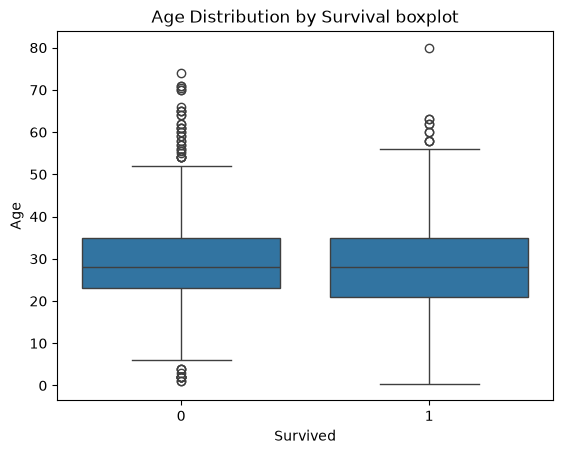

In [101]:
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age Distribution by Survival boxplot")
plt.savefig("age_distribution_by_survival_boxplot.png")
plt.show()

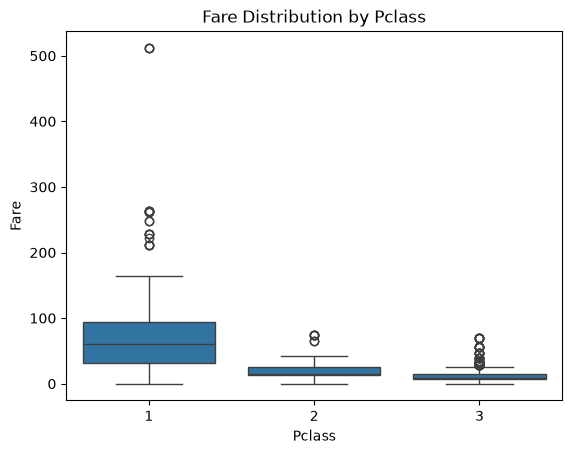

In [102]:
sns.boxplot(x="Pclass", y="Fare", data=df)
plt.title("Fare Distribution by Pclass")
plt.savefig("fare_distribution_by_pclass.png")
plt.show()

some people in 3rd class have bought the tickets in same prizes as that of the 2nd class tickets this might have happened because of lack of tickets or they bought at then end time or something like that (Analyzing the outlier data)

# Feature Engineering

creating familysize column instead of two columns of sibling/spouse and parents/children

<Axes: xlabel='Family_size', ylabel='count'>

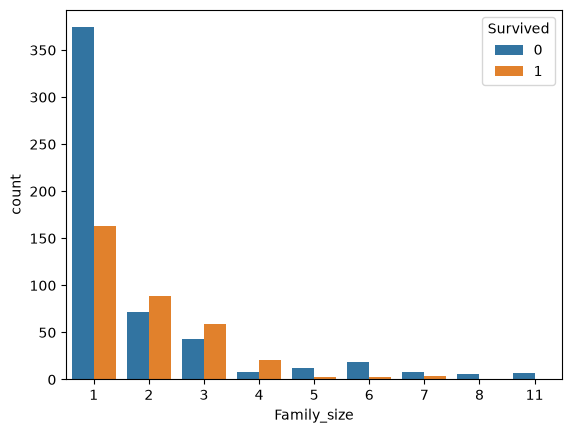

In [82]:
df["Family_size"] = df["SibSp"] + df["Parch"] +1 #adding one for the person themselves

sns.countplot(x="Family_size",hue = "Survived" , data = df)

People with Family size between 2 to 4 were having a good survival chance as helping out less people is easy then helping out many people at the same time

# Preparing Dataset for Machine Learning

In [83]:
df.drop(["Name" , "PassengerId" ,"Ticket"],axis = 1 ,  inplace=True)

Removing Name Passenger ID and Ticket Columns as they are of no use in any data correlation

# Revising the Dataset

In [84]:
df.to_csv("Titanic_revised.csv", index=False)

In [85]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_size
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


In [86]:
df.describe(include='all')

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family_size
count,891.000000,891.000000,891,891.000000,891.000000,891.000000,891.000000,891,891.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,NaN
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,646,NaN
mean,0.383838,2.308642,NaN,29.361582,0.523008,0.381594,32.204208,NaN,1.904602
std,0.486592,0.836071,NaN,13.019697,1.102743,0.806057,49.693429,NaN,1.613459
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,1.000000
25%,0.000000,2.000000,NaN,22.000000,0.000000,0.000000,7.910400,NaN,1.000000
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,1.000000
75%,1.000000,3.000000,NaN,35.000000,1.000000,0.000000,31.000000,NaN,2.000000


In [ ]:
df_new = pd.read_csv('Titanic_revised.csv')

df_new.info() #checking the info of the new dataset to see if all the changes have been made


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    str    
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Embarked     891 non-null    str    
 8   Family_size  891 non-null    int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB
